In [1]:
# Step 1: Data Loading and Overview
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
# Load the dataset
df = pd.read_csv('/content/netflix_titles.csv')

In [5]:
# Display the first few rows and general info
print("First few rows of the dataset:")
df.head()

First few rows of the dataset:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.shape

(8807, 12)

In [7]:
# Check for missing values
print("\nMissing values in each column:")
df.isnull().sum()


Missing values in each column:


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


# **Step 2: Data Cleaning**


In [10]:
# Drop duplicates
df = df.drop_duplicates()
print(f"\nShape after removing duplicates: {df.shape}")


Shape after removing duplicates: (8807, 12)


In [11]:
# Handle missing values (dropping rows with missing values for simplicity)
df = df.dropna()
print(f"Shape after handling missing values: {df.shape}")

Shape after handling missing values: (5332, 12)


In [12]:
# Standardize the 'release_year' column
df['release_year'] = pd.to_datetime(df['release_year'], errors='coerce').dt.year


In [13]:
# Convert 'duration' to numeric if possible
df['duration'] = df['duration'].str.replace(' min', '').str.strip()
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')


# **Step 3: Data Exploration**


In [14]:
df.shape

(5332, 12)

In [15]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1970,TV-MA,125.0,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",1970,TV-14,NaN,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",1970,PG-13,104.0,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",1970,TV-MA,127.0,"Dramas, International Movies",After most of her family is murdered in a terr...
24,s25,Movie,Jeans,S. Shankar,"Prashanth, Aishwarya Rai Bachchan, Sri Lakshmi...",India,"September 21, 2021",1970,TV-14,166.0,"Comedies, International Movies, Romantic Movies",When the father of the man she loves insists t...


In [16]:
# Content Analysis
print("\nContent type distribution:")
print(df['type'].value_counts())


Content type distribution:
type
Movie      5185
TV Show     147
Name: count, dtype: int64


<ipython-input-17-4ae78993f769>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


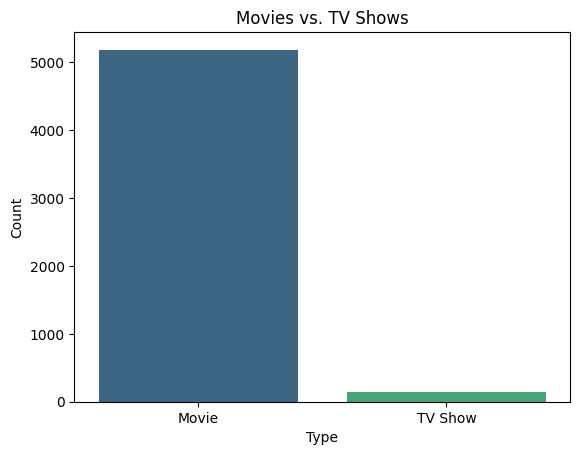

In [17]:
# Plot movies vs. TV shows
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Movies vs. TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

In [21]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [22]:
# Analyze genre distribution
if 'listed_in' in df.columns:  # Replace with actual genre column name if different
    print("\nTop 10 genres:")
    print(df['listed_in'].value_counts().head(10))



Top 10 genres:
listed_in
Dramas, International Movies                        336
Stand-Up Comedy                                     286
Comedies, Dramas, International Movies              257
Dramas, Independent Movies, International Movies    243
Children & Family Movies, Comedies                  179
Dramas, International Movies, Romantic Movies       160
Documentaries                                       156
Comedies, International Movies                      152
Comedies, International Movies, Romantic Movies     143
Dramas                                              133
Name: count, dtype: int64


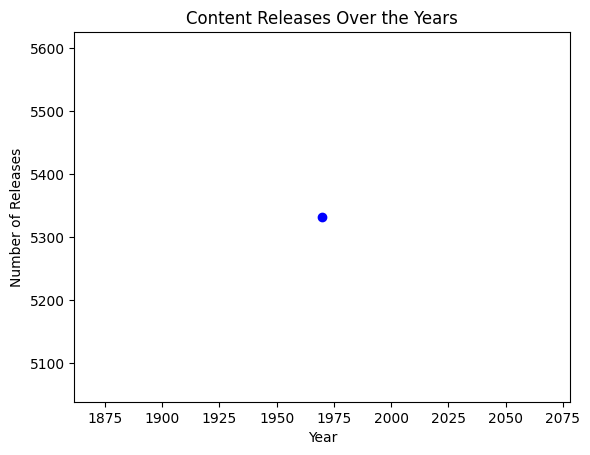

In [23]:
# Trend Analysis: Releases over the years
if 'release_year' in df.columns:
    df['release_year'].value_counts().sort_index().plot(kind='line', color='blue', marker='o')
    plt.title('Content Releases Over the Years')
    plt.xlabel('Year')
    plt.ylabel('Number of Releases')
    plt.show()

# **Step 4: Data Visualization**

<ipython-input-31-ebe563549a29>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='coolwarm')


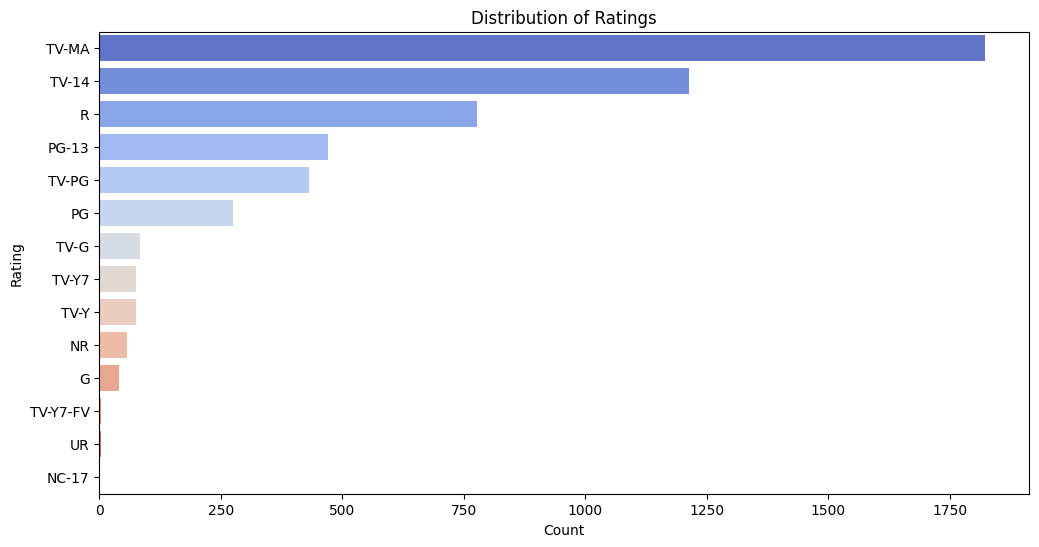

In [31]:
# Count the occurrences of each rating
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Ratings')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

<ipython-input-32-bdabc821f6b6>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


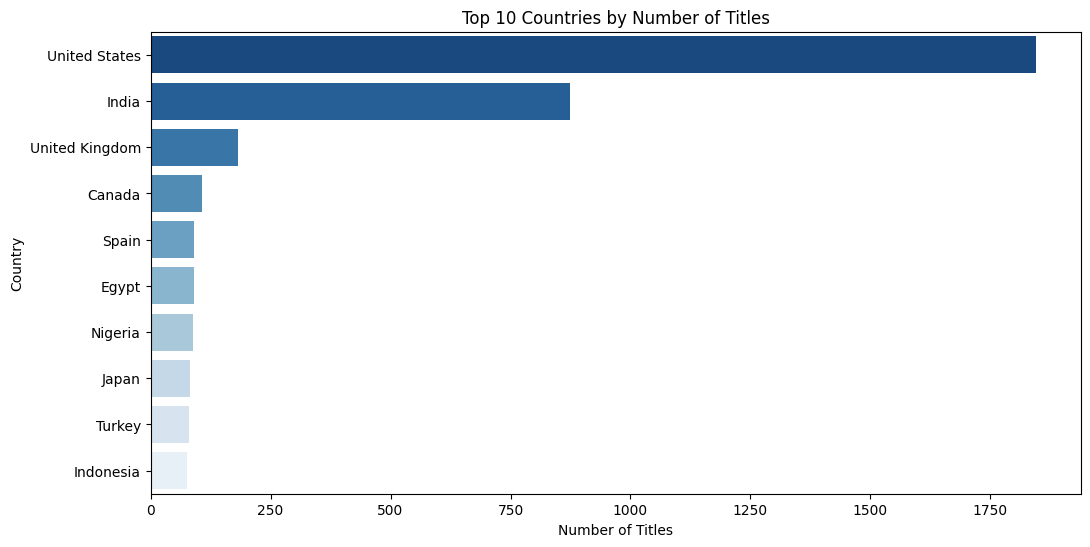

In [32]:
# Top 10 countries with the most content
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

<ipython-input-34-b91895cf3a7d>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(genres), palette='muted')


Text(0, 0.5, 'Genre')

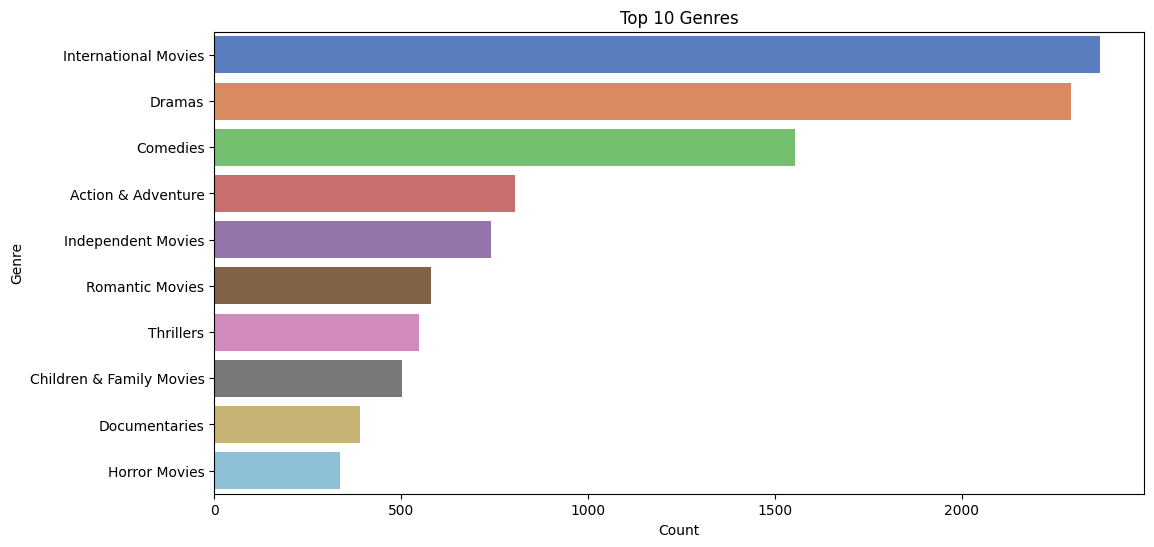

In [34]:
# Extract and count genres
from collections import Counter
all_genres = ','.join(df['listed_in'].dropna()).split(',')
genre_counts = Counter([genre.strip() for genre in all_genres])
top_genres = genre_counts.most_common(10)

# Visualize the top 10 genres
genres, counts = zip(*top_genres)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(genres), palette='muted')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

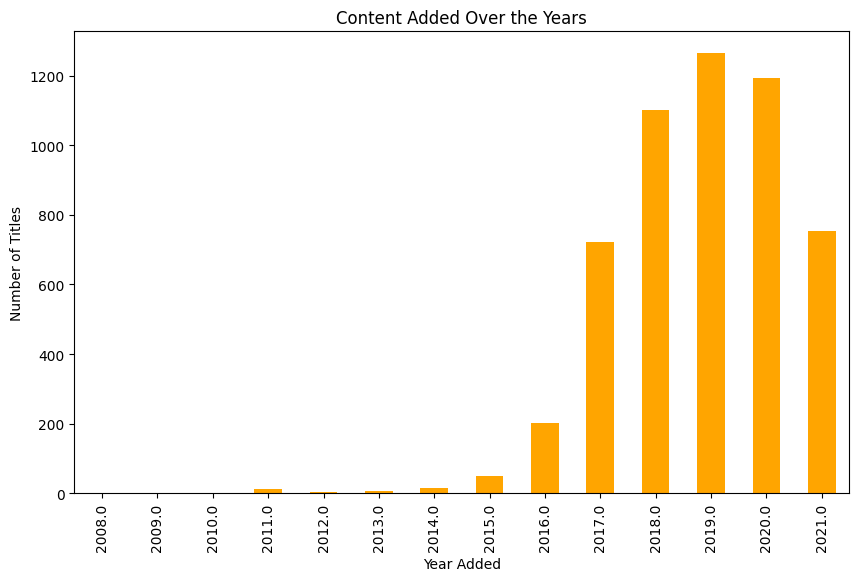

In [35]:
# Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Plot content added by year
added_year = df['date_added'].dt.year.value_counts().sort_index()
plt.figure(figsize=(10, 6))
added_year.plot(kind='bar', color='orange')
plt.title('Content Added Over the Years')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()

<ipython-input-37-640adb35bb19>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='pastel')


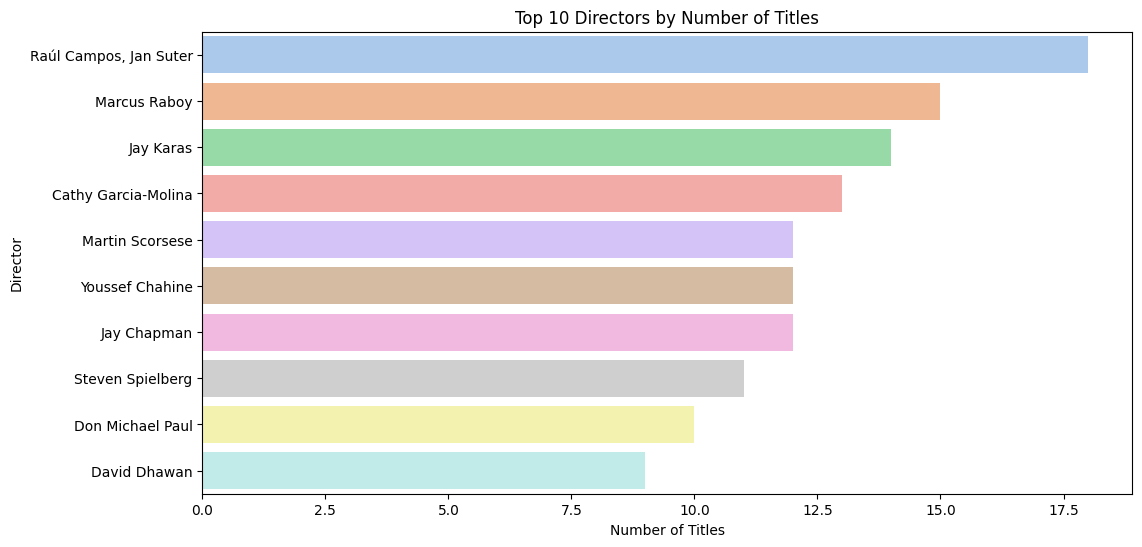

In [37]:
# Most frequent directors
top_directors = df['director'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='pastel')
plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.show()

<ipython-input-38-294c3cb53e05>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(cast_count), y=list(cast_names), palette='Set2')


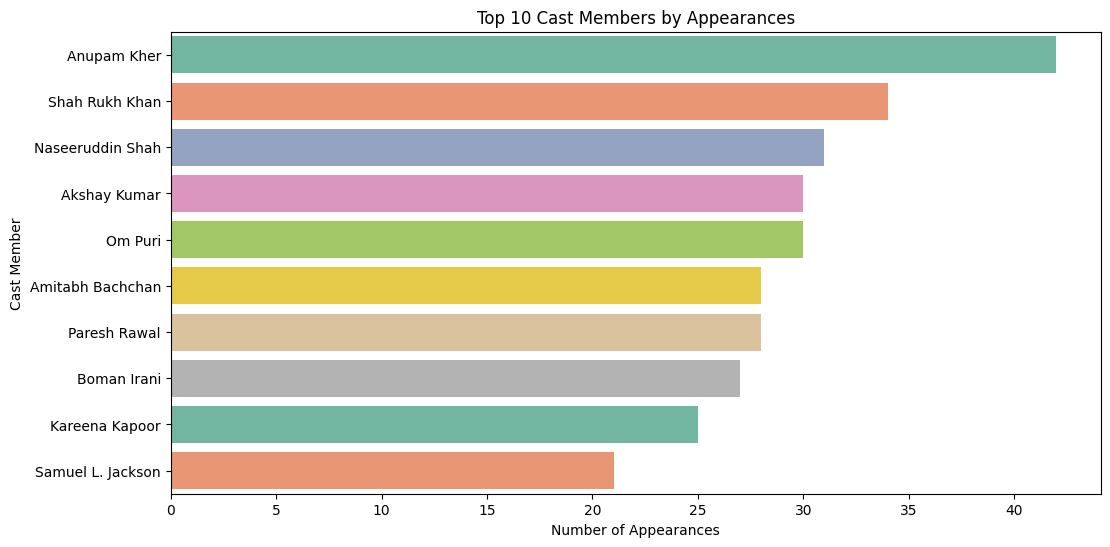

In [38]:
# Most frequent cast members
from itertools import chain
cast_members = df['cast'].dropna().str.split(',').map(lambda x: [i.strip() for i in x])
flat_cast = list(chain(*cast_members))
cast_counts = Counter(flat_cast).most_common(10)

cast_names, cast_count = zip(*cast_counts)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(cast_count), y=list(cast_names), palette='Set2')
plt.title('Top 10 Cast Members by Appearances')
plt.xlabel('Number of Appearances')
plt.ylabel('Cast Member')
plt.show()

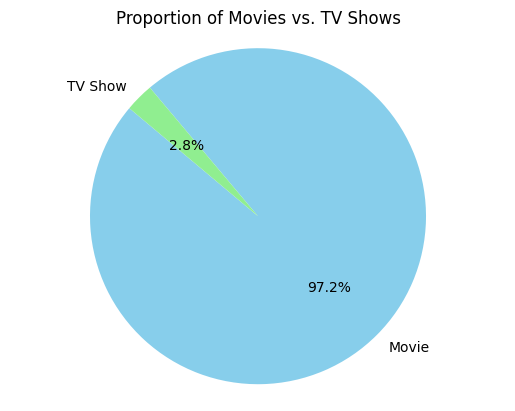

In [25]:
# Pie Chart: Movies vs. TV Shows
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140, colors=['skyblue', 'lightgreen'])
plt.title('Proportion of Movies vs. TV Shows')
plt.axis('equal')  # Equal aspect ratio ensures the pie chart is circular
plt.show()

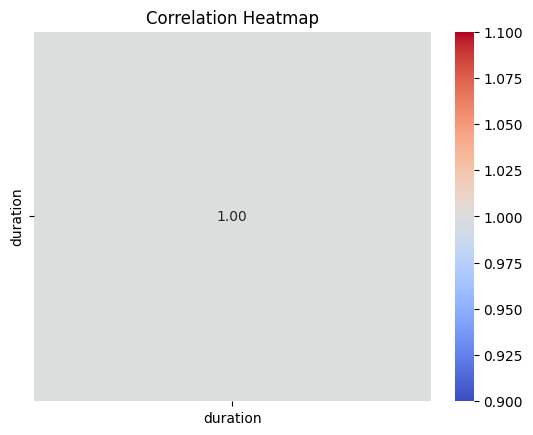

In [26]:
# Heatmap: Correlations between numerical features
numerical_features = df.select_dtypes(include=['float64', 'int64'])
if not numerical_features.empty:
    sns.heatmap(numerical_features.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()